In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import MobileNetV2, mobilenet_v2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Conv2D, Dropout
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

# Set Global Variables

In [2]:
BATCH_SIZE = 8
IMAGE_SIZE = (224, 224)
LEARNING_RATE = 0.0001
EPOCHS = 100

# Load Dataset

In [3]:
data_dir = 'Training'
train_ds = image_dataset_from_directory(
  data_dir,
  seed=123,
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE)

Found 716 files belonging to 2 classes.


In [4]:
data_dir = './Validation/'
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  seed=123,
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE)

Found 180 files belonging to 2 classes.


In [5]:
data_dir = 'Testing'
test_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  seed=123,
  image_size=IMAGE_SIZE,
  batch_size=BATCH_SIZE)

Found 224 files belonging to 2 classes.


In [6]:
class_names = train_ds.class_names
print(class_names)

['Not Smoking', 'Smoking']


# Visualize Dataset

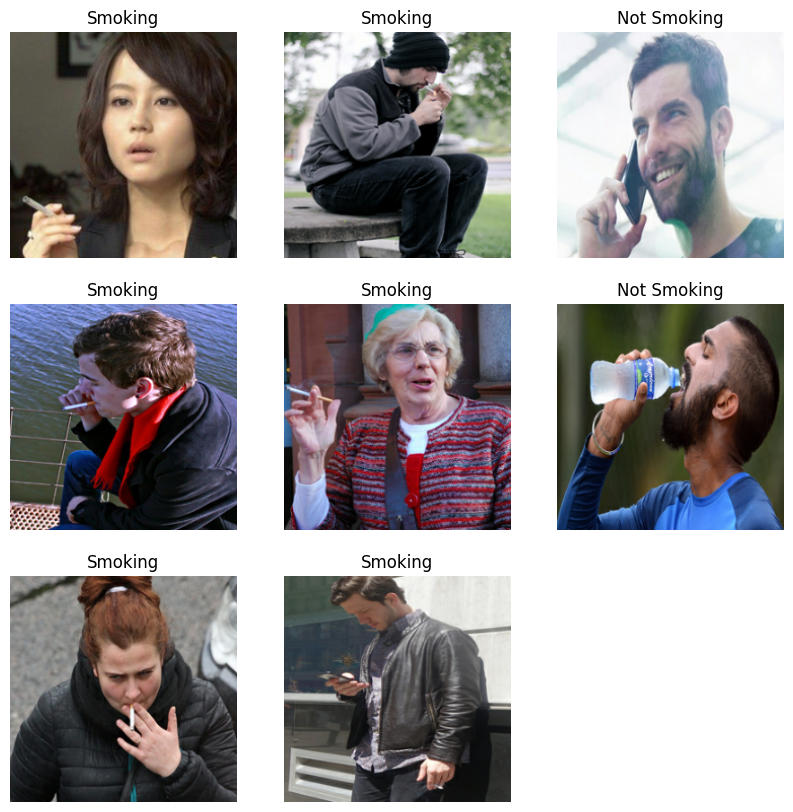

In [7]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(8):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [8]:
for image_batch, labels_batch in train_ds:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

(8, 224, 224, 3)
(8,)


# AUTOTUNE Dataset

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Data Augmentation (Because we have a small dataset)

In [10]:
data_augmentation = Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomRotation(0.2),
])

# Create Model (Using MobileNetV2) No Fine-Tuning

## Preprocess Input

In [11]:
preprocess_input = mobilenet_v2.preprocess_input

## Creating Base Model

In [12]:
# Create the base model from the pre-trained model MobileNet V2
IMG_SHAPE = IMAGE_SIZE + (3,)
base_model = MobileNetV2(input_shape=IMG_SHAPE,
                                               include_top=False,
                                               weights='imagenet')

In [13]:
base_model.summary()

Model: "mobilenetv2_1.00_224"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 Conv1 (Conv2D)                 (None, 112, 112, 32  864         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 bn_Conv1 (BatchNormalization)  (None, 112, 112, 32  128         ['Conv1[0][0]']                  
                                )                                              

## Freeze Base Model

In [14]:
base_model.trainable = False

## Add Classification Head

### Get Feature batch

In [15]:
image_batch, label_batch = next(iter(train_ds))
feature_batch = base_model(image_batch)
print(feature_batch.shape)

(8, 7, 7, 1280)


### Global Average Pooling

In [16]:
global_average_layer = GlobalAveragePooling2D()
feature_batch_average = global_average_layer(feature_batch)
print(feature_batch_average.shape)

(8, 1280)


## Create Model Structure

In [19]:
inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = Conv2D(32, 3, activation='relu')(x)
x = global_average_layer(x)
x = Dropout(0.2)(x)
outputs = Dense(1, activation='sigmoid')(x)
model = tf.keras.Model(inputs, outputs)

In [20]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 224, 224, 3)       0         
                                                                 
 tf.math.truediv_1 (TFOpLamb  (None, 224, 224, 3)      0         
 da)                                                             
                                                                 
 tf.math.subtract_1 (TFOpLam  (None, 224, 224, 3)      0         
 bda)                                                            
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                             

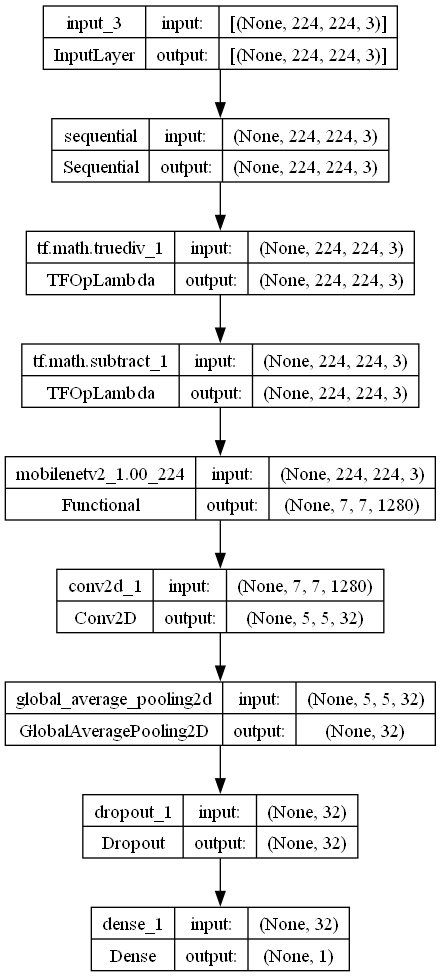

In [21]:
tf.keras.utils.plot_model(model, show_shapes=True)

## Compile Model

In [22]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss=tf.keras.losses.BinaryCrossentropy(),
              metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy')])

## Train Model

In [23]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, verbose=1),
]

history = model.fit(train_ds, epochs=EPOCHS, validation_data=val_ds, callbacks=callbacks)

Epoch 1/20
90/90 [==============================] - 13s 90ms/step - loss: 0.6583 - accuracy: 0.6411 - val_loss: 0.3798 - val_accuracy: 0.8611
Epoch 2/20
90/90 [==============================] - 6s 70ms/step - loss: 0.4841 - accuracy: 0.7640 - val_loss: 0.2637 - val_accuracy: 0.9167
Epoch 3/20
90/90 [==============================] - 6s 68ms/step - loss: 0.4350 - accuracy: 0.7975 - val_loss: 0.2452 - val_accuracy: 0.8889
Epoch 4/20
90/90 [==============================] - 6s 69ms/step - loss: 0.3767 - accuracy: 0.8394 - val_loss: 0.1890 - val_accuracy: 0.9333
Epoch 5/20
90/90 [==============================] - 6s 69ms/step - loss: 0.3409 - accuracy: 0.8589 - val_loss: 0.1721 - val_accuracy: 0.9500
Epoch 6/20
90/90 [==============================] - 6s 69ms/step - loss: 0.3350 - accuracy: 0.8450 - val_loss: 0.1662 - val_accuracy: 0.9500
Epoch 7/20
90/90 [==============================] - 6s 70ms/step - loss: 0.3004 - accuracy: 0.8855 - val_loss: 0.1394 - val_accuracy: 0.9556
Epoch 8/20
9

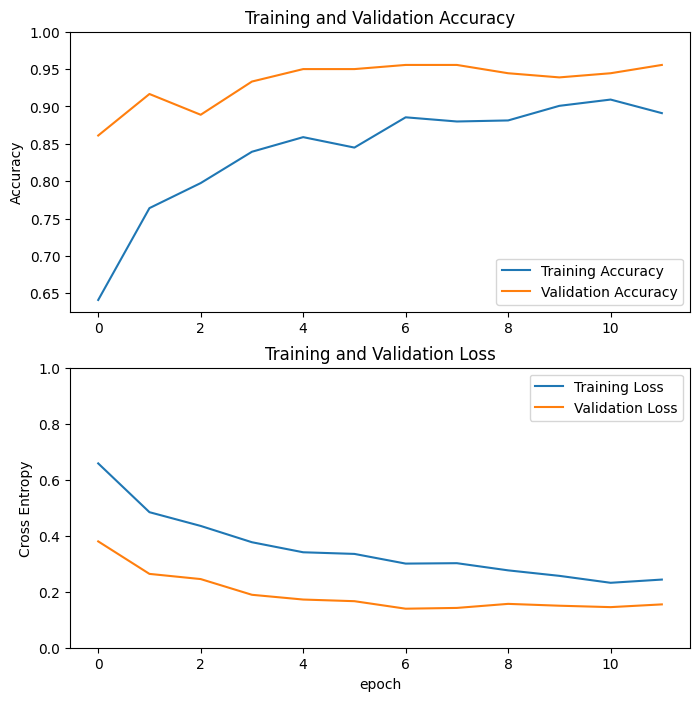

In [24]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.ylabel('Accuracy')
plt.ylim([min(plt.ylim()),1])
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.ylabel('Cross Entropy')
plt.ylim([0,1.0])
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

# Fine-Tuning Model

## Unfreeze Base Model

In [25]:
base_model.trainable = True

In [26]:
# Let's take a look to see how many layers are in the base model
print("Number of layers in the base model: ", len(base_model.layers))

# Fine-tune from this layer onwards
fine_tune_at = 100

# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
  layer.trainable = False

Number of layers in the base model:  154


## Compile Model

In [27]:
model.compile(loss=tf.keras.losses.BinaryCrossentropy(),
              optimizer = tf.keras.optimizers.RMSprop(learning_rate=LEARNING_RATE/10),
              metrics=[tf.keras.metrics.BinaryAccuracy(threshold=0.5, name='accuracy')])

In [28]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 sequential (Sequential)     (None, 224, 224, 3)       0         
                                                                 
 tf.math.truediv_1 (TFOpLamb  (None, 224, 224, 3)      0         
 da)                                                             
                                                                 
 tf.math.subtract_1 (TFOpLam  (None, 224, 224, 3)      0         
 bda)                                                            
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                             

## Train Model

In [29]:
fine_tune_epochs = 10
total_epochs =  EPOCHS + fine_tune_epochs

history_fine = model.fit(train_ds,
                         epochs=total_epochs,
                         initial_epoch=len(history.epoch),
                         validation_data=val_ds)

Epoch 13/30


90/90 [==============================] - 16s 108ms/step - loss: 0.2681 - accuracy: 0.8757 - val_loss: 0.1465 - val_accuracy: 0.9444
Epoch 14/30
90/90 [==============================] - 8s 94ms/step - loss: 0.2171 - accuracy: 0.9092 - val_loss: 0.1438 - val_accuracy: 0.9500
Epoch 15/30
90/90 [==============================] - 8s 95ms/step - loss: 0.2375 - accuracy: 0.9008 - val_loss: 0.1009 - val_accuracy: 0.9556
Epoch 16/30
90/90 [==============================] - 9s 97ms/step - loss: 0.2083 - accuracy: 0.9260 - val_loss: 0.2166 - val_accuracy: 0.9000
Epoch 17/30
90/90 [==============================] - 9s 96ms/step - loss: 0.1926 - accuracy: 0.9162 - val_loss: 0.1416 - val_accuracy: 0.9500
Epoch 18/30
90/90 [==============================] - 9s 97ms/step - loss: 0.1782 - accuracy: 0.9274 - val_loss: 0.0906 - val_accuracy: 0.9667
Epoch 19/30
90/90 [==============================] - 9s 96ms/step - loss: 0.1487 - accuracy: 0.9399 - val_loss: 0.1521 - val_accuracy: 0.9389
Epoch 20/30
90/9

In [30]:
acc += history_fine.history['accuracy']
val_acc += history_fine.history['val_accuracy']

loss += history_fine.history['loss']
val_loss += history_fine.history['val_loss']

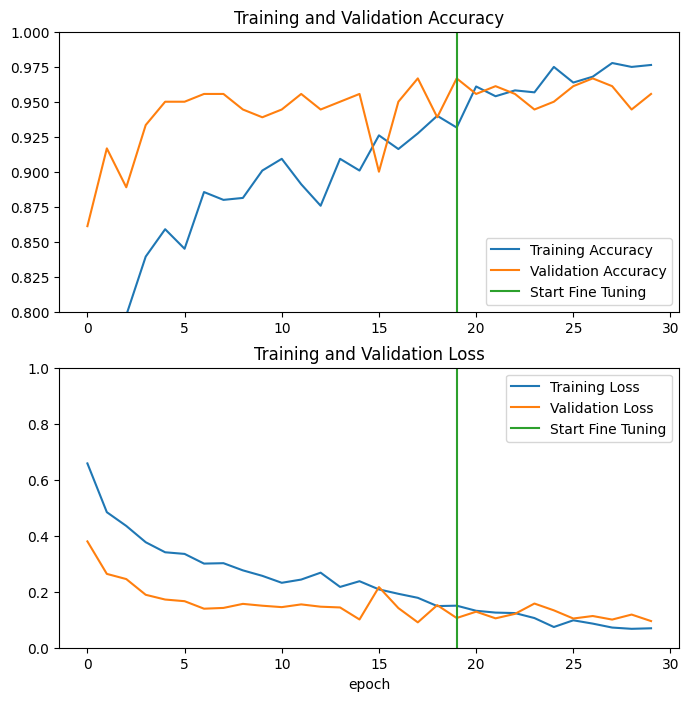

In [31]:
plt.figure(figsize=(8, 8))
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.ylim([0.8, 1])
plt.plot([EPOCHS-1,EPOCHS-1],
          plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.ylim([0, 1.0])
plt.plot([EPOCHS-1,EPOCHS-1],
         plt.ylim(), label='Start Fine Tuning')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('epoch')
plt.show()

# Model Evaluation

In [32]:
loss, accuracy = model.evaluate(test_ds)
print('Test accuracy :', accuracy)

28/28 [==============================] - 2s 46ms/step - loss: 0.1590 - accuracy: 0.9241
Test accuracy : 0.9241071343421936


Predictions:
 [1 1 1 1 1 1 1 1]
Labels:
 [0 0 1 1 0 1 0 1]


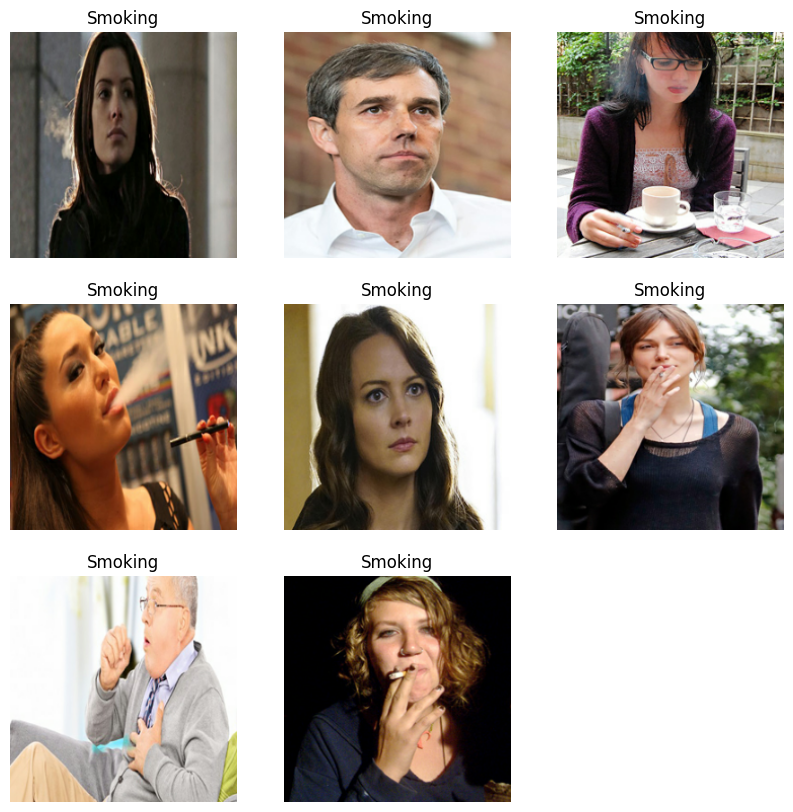

In [33]:
# Retrieve a batch of images from the test set
image_batch, label_batch = test_ds.as_numpy_iterator().next()
predictions = model.predict_on_batch(image_batch).flatten()

# Apply a sigmoid since our model returns logits
predictions = tf.nn.sigmoid(predictions)
predictions = tf.where(predictions < 0.5, 0, 1)

print('Predictions:\n', predictions.numpy())
print('Labels:\n', label_batch)

plt.figure(figsize=(10, 10))
for i in range(8):
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(image_batch[i].astype("uint8"))
  plt.title(class_names[predictions[i]])
  plt.axis("off")

In [63]:
# Function to generate Grad-CAM heatmap
def get_gradcam_heatmap(model, image, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(image)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Function to display heatmap
def display_gradcam(image, heatmap, alpha=0.5):
    heatmap = np.uint8(255 * heatmap)
    jet = plt.get_cmap("jet")
    jet_colors = jet(np.arange(256))[:, :3]
    jet_heatmap = jet_colors[heatmap]
    jet_heatmap = tf.keras.preprocessing.image.array_to_img(jet_heatmap)
    jet_heatmap = jet_heatmap.resize((image.shape[1], image.shape[0]))
    jet_heatmap = tf.keras.preprocessing.image.img_to_array(jet_heatmap)
    superimposed_img = jet_heatmap * alpha + image
    superimposed_img = tf.keras.preprocessing.image.array_to_img(superimposed_img)
    return superimposed_img

# Example usage
# Assuming you have a trained model named 'model' and an input image 'img'
last_conv_layer_name = 'conv2d_1'  # Last conv layer name for MobileNetV2; you may need to confirm the exact name

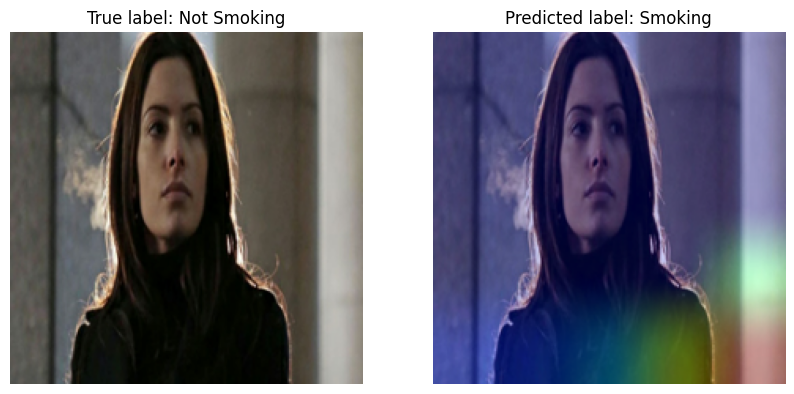

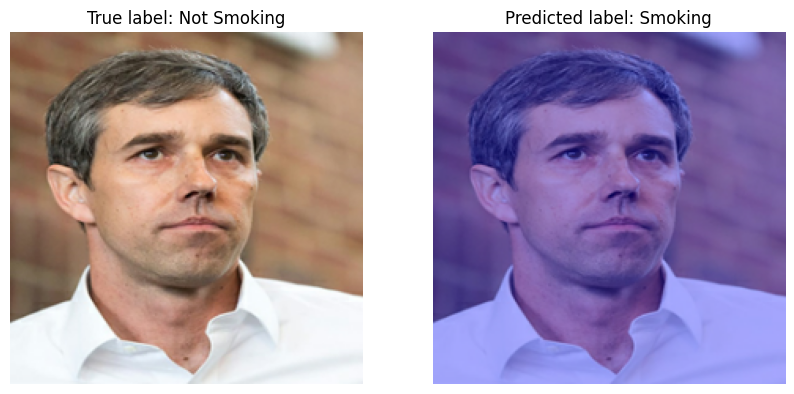

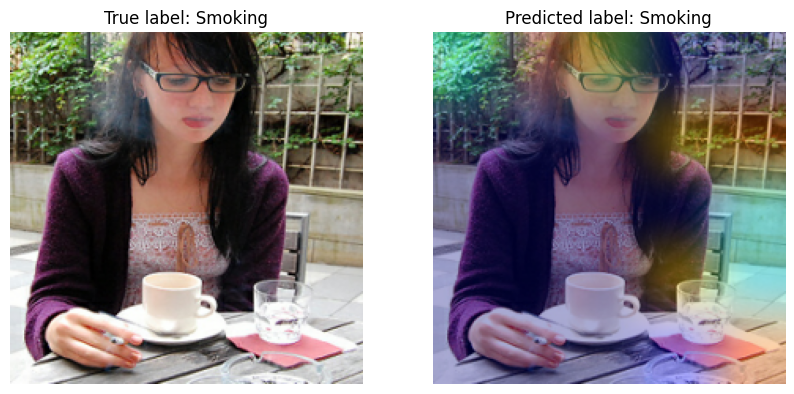

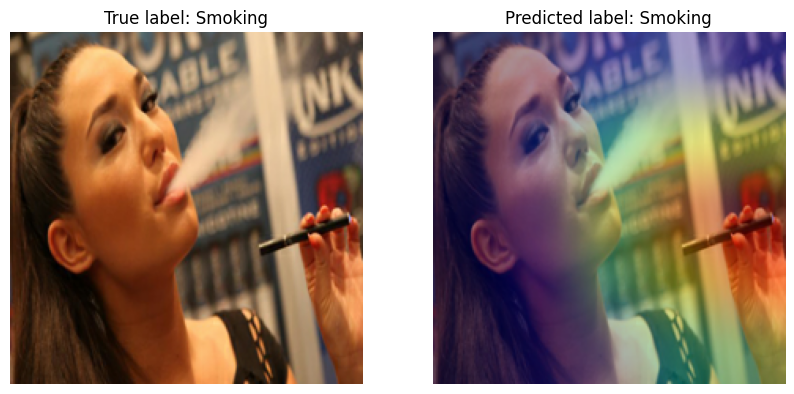

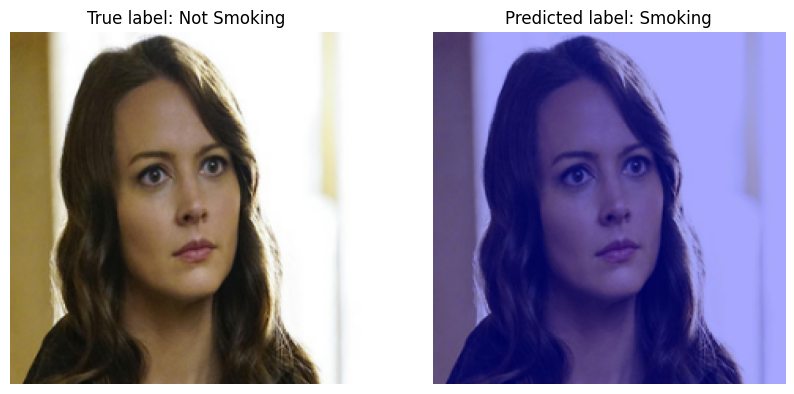

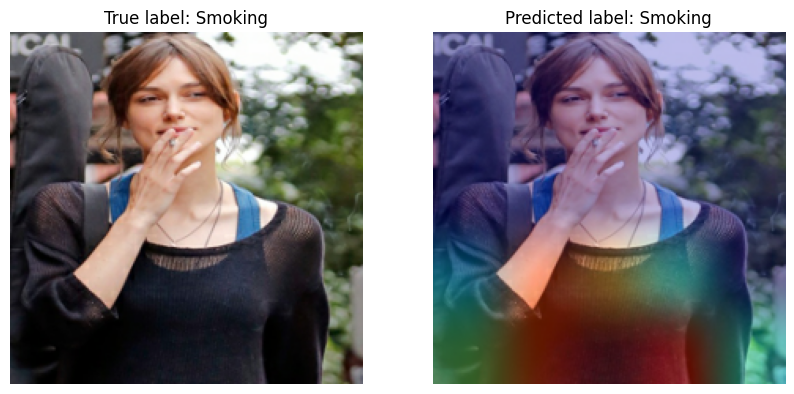

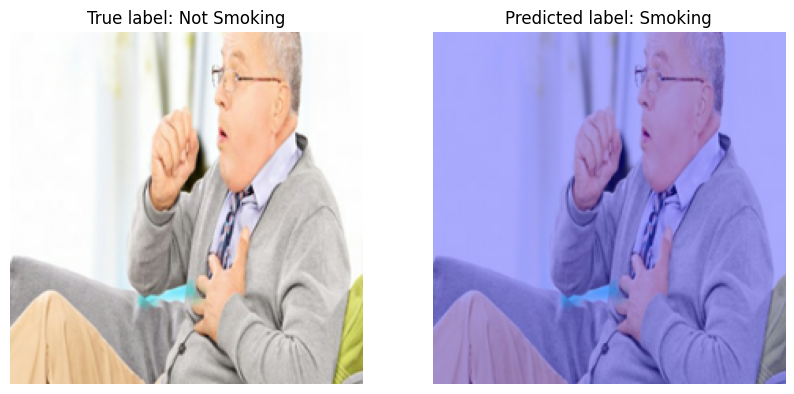

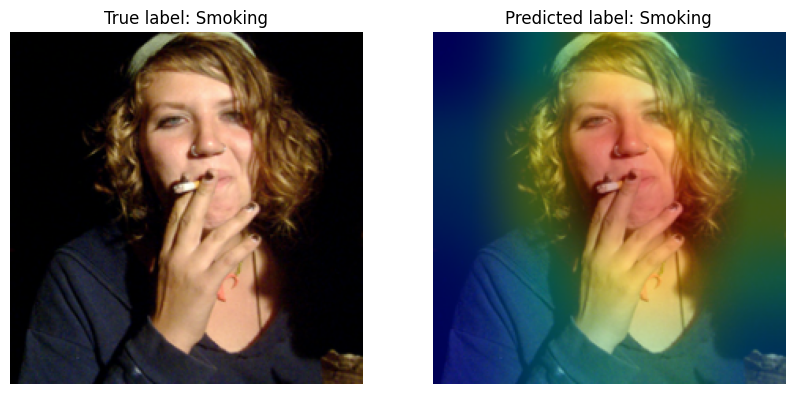

In [66]:

# Get the image from test data
image_batch, label_batch = test_ds.as_numpy_iterator().next()

for i in range(BATCH_SIZE):
    # Get the first image
    img = image_batch[i]

    # Get image array
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Get the true label of the image
    true_label = class_names[label_batch[i]]

    # Get the predicted label of the image
    predictions = model.predict_on_batch(img_array).flatten()

    # Apply a sigmoid since our model returns logits
    predictions = tf.nn.sigmoid(predictions)

    # Get the predicted label
    predicted_label = class_names[tf.where(predictions < 0.5, 0, 1).numpy()[0]]

    # Get the Grad-CAM heatmap
    heatmap = get_gradcam_heatmap(model, img_array, last_conv_layer_name)

    # Display the image and the Grad-CAM heatmap
    superimposed_img = display_gradcam(img, heatmap)

    plt.figure(figsize=(10, 10))
    plt.subplot(1, 2, 1)
    plt.imshow(img.astype("uint8"))
    plt.axis('off')
    plt.title(f'True label: {true_label}')
    plt.subplot(1, 2, 2)
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title(f'Predicted label: {predicted_label}')
    plt.show()